In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch
import matplotlib.pyplot as plt
from geodesic_toolbox import *
from functools import partial
from sklearn.datasets import make_swiss_roll
from utils import *
from scipy.special import factorial 

# 2D Dummy data

In [2]:
device = "cpu"

In [3]:
def get_bounds(embeddings: torch.Tensor, margin: float = 0.0) -> torch.Tensor:
    """
    Compute the bounds of the embeddings.

    Parameters:
    ----------
    embeddings : torch.Tensor (n_points, 2)
        The embeddings of the points.
    margin : float
        Margin scaling factor to add to the bounds. (default is 0)
        This is useful to avoid points being too close to the edges of the plot.

    Returns:
    -------
    torch.Tensor (4,)
        [min_x, max_x, min_y, max_y], the bounds of the embeddings.
    """
    min_x, max_x = embeddings[:, 0].min(), embeddings[:, 0].max()
    min_y, max_y = embeddings[:, 1].min(), embeddings[:, 1].max()
    # Add margin to the bounds
    min_x -= margin * (max_x - min_x)
    max_x += margin * (max_x - min_x)
    min_y -= margin * (max_y - min_y)
    max_y += margin * (max_y - min_y)
    # Ensure the bounds are in the correct order
    min_x, max_x = min(min_x, max_x), max(min_x, max_x)
    min_y, max_y = min(min_y, max_y), max(min_y, max_y)
    # Create a tensor with the bounds
    bounds = [min_x, max_x, min_y, max_y]
    bounds = torch.tensor(bounds)
    return bounds

def get_spiral(n_pts: int, freq: float, sigma: float = 0.1, t_max: float = 4 * np.pi):
    # Sample uniformly in arc length on the noiseless spiral, then add noise.
    t_dense = np.linspace(0.0, t_max, max(5000, 10 * n_pts))
    speed = np.sqrt(1.0 + (freq * t_dense) ** 2)
    ds = 0.5 * (speed[1:] + speed[:-1]) * np.diff(t_dense)
    s_dense = np.concatenate(([0.0], np.cumsum(ds)))
    s_uniform = np.linspace(0.0, s_dense[-1], n_pts)
    t = np.interp(s_uniform, s_dense, t_dense)

    x = t * np.cos(freq * t) + np.random.normal(0, sigma, n_pts)
    y = t * np.sin(freq * t) + np.random.normal(0, sigma, n_pts)
    X = np.stack([x, y], axis=1)

    # Normalize the data
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    s = s_uniform / s_uniform[-1]
    X = torch.from_numpy(X).double().to(device)
    s = torch.from_numpy(s).double().to(device)
    return X, s


def get_x_plt(resolution: int, bounds: tuple = (-2, 2, -2, 2)):
    x = np.linspace(bounds[0], bounds[1], resolution)
    y = np.linspace(bounds[2], bounds[3], resolution)
    xx, yy = np.meshgrid(x, y)
    X_plt = np.stack([xx.flatten(), yy.flatten()], axis=1)
    return torch.from_numpy(X_plt).float().to(device)


def spiral_omega(z: torch.Tensor, freq: float) -> torch.Tensor:
    """
    Compute the omega vector field for a spiral.

    Parameters:
    ----------
    z : torch.Tensor (n_points, 2)
        The input points in 2D space.
    freq : float
        The frequency of the spiral.

    Returns:
    -------
    torch.Tensor (n_points, 2)
        The omega vector field at the input points.
    """
    x = z[:, 0]
    y = z[:, 1]
    t = torch.sqrt(x**2 + y**2)
    omega_x = -freq * y / (t + 1e-8)  # Avoid division by zero
    omega_y = freq * x / (t + 1e-8)   # Avoid division by zero
    omega = torch.stack([omega_x, omega_y], dim=1)
    return omega / torch.norm(omega, dim=1, keepdim=True)  # Normalize the vector field




In [4]:
class CometricSpiral(torch.nn.Module):
    def __init__(self, cometric:CoMetric, freq: float = 1.0):
        super().__init__()
        self.cometric = cometric
        self.freq = freq

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        omega = spiral_omega(z, freq=self.freq)
        norm_omega = self.cometric.cometric(z, omega)
        omega = omega / (norm_omega.unsqueeze(1) + 1e-8)  # Avoid division by zero
        return omega

In [5]:
N = 3000
X, t = get_spiral(3000, freq=1.0, sigma=0.5)
X = X.to(torch.float).to(device)
base_cometric = CentroidsCometric(X, IdentityCoMetric()(X),kappa=1.0).to(device)
base_cometric = IdentityCoMetric().to(device)

omega_spiral_ = partial(spiral_omega, freq=1.0)
omega_X = omega_spiral_(X)
bounds = get_bounds(X, margin=0.2)


Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 21026.08batch/s]


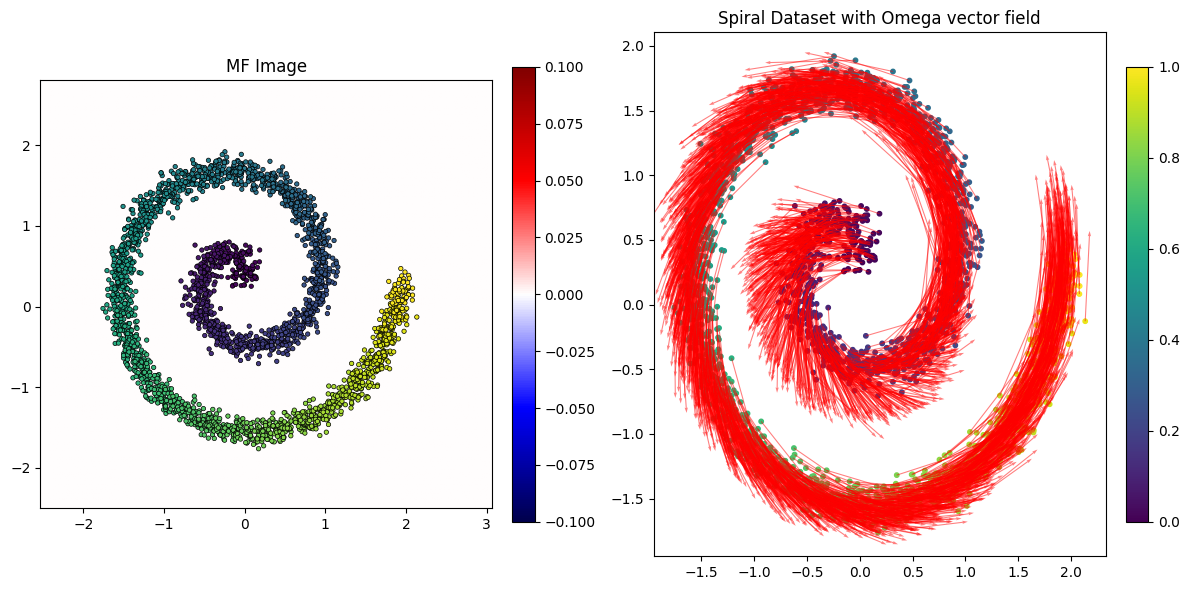

In [6]:
mf = get_mf_image(base_cometric, X, bounds)


fig, axes = plt.subplots(1,2, figsize=(12, 6))
im = axes[0].imshow(mf.cpu().numpy(), cmap="seismic", origin="lower", extent=bounds)
t_cbar = axes[0].scatter(
    X[:, 0].cpu(), X[:, 1].cpu(), c=t.cpu(), cmap="viridis", s=10, edgecolor="k", linewidth=0.5
)
axes[0].set_title("MF Image")
axes[1].scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=t.cpu(), cmap="viridis", s=10)
axes[1].quiver(X[::, 0].cpu(), X[::, 1].cpu(), omega_X[::, 0].cpu(), omega_X[::, 1].cpu(), color='red', alpha=0.5, scale=5, angles='xy')
axes[1].set_title("Spiral Dataset with Omega vector field")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(t_cbar, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.tight_layout()
plt.show()

In [7]:
omega_true = CometricSpiral(base_cometric, freq=1.0)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=0.5
)

In [8]:
# solver_r = SolverGraph(cometric=base_cometric,
#                        data=X,
#                        n_neighbors=8,
#                        )
solver_f = SolverGraphFinsler(finsler_metric=randers_metric,
                            data=X,
                            n_neighbors=8,
                            )

Initialize Graph: 100%|██████████| 47/47 [00:03<00:00, 14.03batch/s]


Computing predecessors...
Done.


In [9]:
dst_mat = solver_f.W
valid_edges_plt = dst_mat > 0
valid_edges = valid_edges_plt.nonzero(as_tuple=False)

epsilon = find_espilon(dst_mat)*2
W = torch.exp(-dst_mat / epsilon) # (N, N)
mu0 = factorial(2-1)
mu1 = factorial(2)
# W = 1/epsilon**2 * torch.exp(-dst_mat**2 / epsilon**2)
# mu0 = 1/2 * torch.lgamma(torch.tensor(2.0)/2).exp()
# mu1 = torch.lgamma(torch.tensor(3.0)/2).exp()

D = torch.diag_embed(torch.sum(W, dim=1)) 
D_prime = torch.diag_embed(torch.sum(W, dim=0))
Q = (D + D_prime) / 2
W_theta = torch.inverse(Q) @ W @ torch.inverse(Q)
D_theta = torch.diag_embed(torch.sum(W_theta, dim=1))
D_theta_prime = torch.diag_embed(torch.sum(W_theta, dim=0))
D_theta_s = (D_theta + D_theta_prime) / 2
D_theta_a = (D_theta - D_theta_prime) / 2
W_theta_s = (W_theta + W_theta.T) / 2
W_theta_a = (W_theta - W_theta.T) / 2

Id = torch.eye(W_theta.shape[0]).to(W_theta.device).to(W_theta.dtype)
P_theta_s = torch.inverse(D_theta_s) @ W_theta_s - Id
P_theta_a = torch.inverse(D_theta_s) @ W_theta_a - torch.inverse(D_theta_s) @ D_theta_a

In [10]:
class OmegaModel(torch.nn.Module):
    """
    Vector field model for the omega vector field in Randers metrics. 
    This model takes in 2D coordinates and outputs a 2D vector field.
    It also enforces ||omega||_2 < 1.
    """
    def __init__(self, d:int, hidden_dims:list[int]=[64, 64]):
        super().__init__()
        layers = []
        input_dim = d
        for hidden_dim in hidden_dims:
            layers.append(torch.nn.Linear(input_dim, hidden_dim))
            layers.append(torch.nn.GELU())
            input_dim = hidden_dim
        layers.append(torch.nn.Linear(input_dim, d))
        self.model = torch.nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        omega = self.model(x)
        # Enforce ||omega||_2 < 1
        omega_norm = torch.norm(omega, dim=1, keepdim=True)
        omega = omega / (omega_norm + 1e-8)  # Avoid division by zero
        return omega_norm.sigmoid() * omega  # Scale by sigmoid to ensure ||omega|| < 1

In [11]:
P_theta_a
# torch.linalg.eigvals(P_theta_a)
eig_vals, eig_vecs = torch.linalg.eig(P_theta_a)
K = eig_vecs.shape[1] //2
eig_vecs = eig_vecs[:, :K]  # Take the first K eigenvectors corresponding to the largest eigenvalues
eig_vals = eig_vals[:K]
grad_phi = build_grad_phi(X, valid_edges, eig_vecs) # (N, K, D)


100%|██████████| 3000/3000 [00:02<00:00, 1450.92it/s]


In [12]:
# Embed X in low dim using IsoMap
from sklearn.manifold import Isomap, SpectralEmbedding

embedding = Isomap(n_neighbors=8, n_components=2)
X_low = embedding.fit_transform(X.cpu().numpy())
# embedding = SpectralEmbedding(n_neighbors=8, n_components=2, affinity='precomputed', random_state=42)
# X_low = embedding.fit_transform(P_theta_s.cpu().numpy())
X_low = torch.from_numpy(X_low).float().to(device)

In [13]:
# K = N // 2
# # Dummy eigenvalues (power law)
# # eig_vals = torch.randn(K, device=device) # (K,)
# eig_vals = torch.arange(1, K+1, device=device).double() ** (-2) # (K,)
# # Dummy eigenvectors
# # eig_vecs = torch.randn(N, K, device=device) # (N, K)
# eig_vecs =  (X @ X.T)[:, :K].clone()
# grad_phi = build_grad_phi(X, valid_edges, eig_vecs) # (N, K, D)

In [14]:
omega_model = OmegaModel(d=2, hidden_dims=[64, 64]).to(device)
randers = RandersMetrics(base_cometric=IdentityCoMetric(), omega=omega_model, beta=1.0)

omega_model(torch.randn(1,2).to(device))

tensor([[ 0.5189, -0.2996]], grad_fn=<MulBackward0>)

In [15]:
# Dummy batch
B = 128
idx_i = torch.randint(0, X.shape[0], (B,), device=device)


X_i = X[idx_i].requires_grad_(True) # (B, D)
phi_i = eig_vecs[idx_i, :] # (B, K)
grad_phi_i = grad_phi[idx_i, :, :] # (B, K, D)
loss = reconstruction_loss(X_i, phi_i, eig_vals, grad_phi_i, randers, mu0, mu1)
loss

tensor(0.4626, grad_fn=<MeanBackward0>)

In [16]:
optim = torch.optim.Adam(omega_model.parameters(), lr=1e-3)

idx_shuffled = torch.randperm(X.shape[0], device=device)

loss_list = []
pbar = tqdm(range(0,500),desc="Training", unit="epoch")
# for epoch in range(50):
for epoch in pbar:
    loss_epoch = []
    # pbar = tqdm(range(0, X.shape[0], B), desc="Training", unit="batch")
    pbar_ = range(0, X.shape[0], B)
    for start in pbar_:
        end = min(start + B, X.shape[0])
        idx_i = idx_shuffled[start:end]
        # X_i = X[idx_i].requires_grad_(True) # (B, D)
        X_i = X_low[idx_i].requires_grad_(True) # (B, D)
        phi_i = eig_vecs[idx_i, :] # (B, K)
        grad_phi_i = grad_phi[idx_i, :, :] # (B, K, D)
        loss = reconstruction_loss(X_i, phi_i, eig_vals, grad_phi_i, randers, mu0, mu1)
        optim.zero_grad()
        loss.backward()
        optim.step()
        loss_epoch.append(loss.item())
    loss_epoch_mean = np.mean(loss_epoch)
    pbar.set_postfix({"loss": loss_epoch_mean})
    loss_list.append(loss_epoch_mean)

Training:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training: 100%|██████████| 500/500 [00:57<00:00,  8.73epoch/s, loss=0.432]


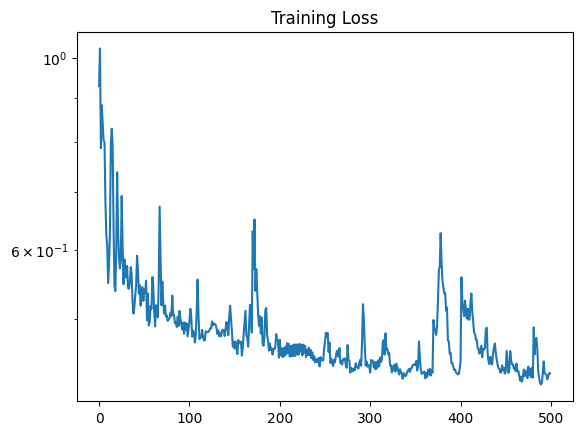

In [17]:
plt.plot(loss_list)
plt.title("Training Loss")
plt.yscale("log")

Text(0.5, 1.0, 'Learned Omega vector field')

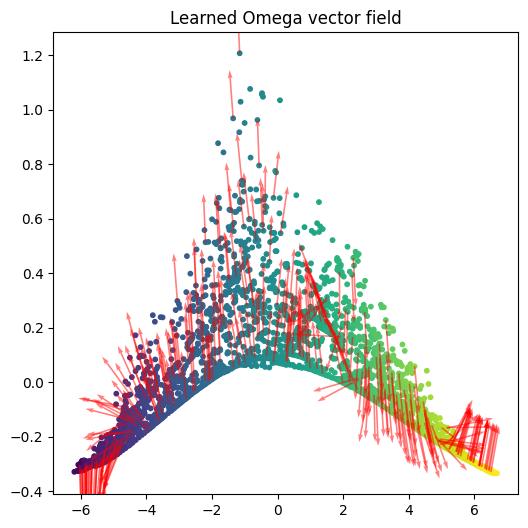

In [18]:
omega_X_tilde = omega_model(X_low).detach()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X_low[:, 0].cpu(), X_low[:, 1].cpu(), c=t.cpu(), cmap="viridis", s=10)
ax.quiver(X_low[::10, 0].cpu(), X_low[::10, 1].cpu(), omega_X_tilde[::10, 0].cpu(), omega_X_tilde[::10, 1].cpu(), color='red', alpha=0.5, scale=5, angles='xy')
ax.set_title("Learned Omega vector field")

Computing magnification factor: 100%|██████████| 79/79 [00:00<00:00, 38099.35batch/s]

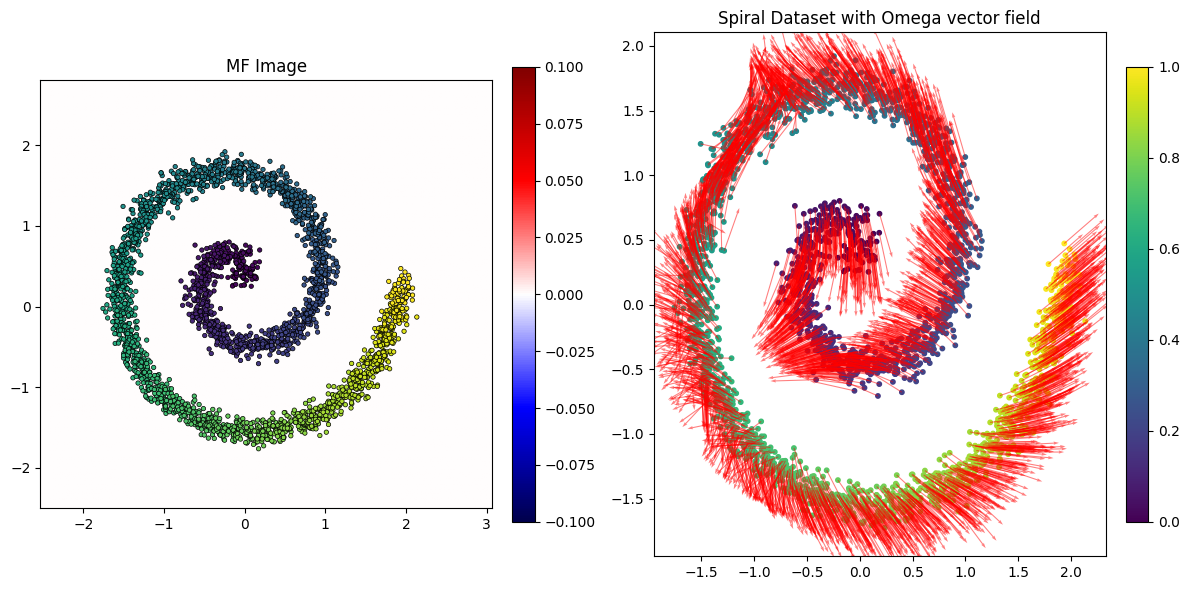

In [19]:
mf = get_mf_image(base_cometric, X, bounds)


fig, axes = plt.subplots(1,2, figsize=(12, 6))
im = axes[0].imshow(mf.cpu().numpy(), cmap="seismic", origin="lower", extent=bounds)
t_cbar = axes[0].scatter(
    X[:, 0].cpu(), X[:, 1].cpu(), c=t.cpu(), cmap="viridis", s=10, edgecolor="k", linewidth=0.5
)
axes[0].set_title("MF Image")
axes[1].scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=t.cpu(), cmap="viridis", s=10)
axes[1].quiver(X[::, 0].cpu(), X[::, 1].cpu(), omega_X_tilde[::, 0].cpu(), omega_X_tilde[::, 1].cpu(), color='red', alpha=0.5, scale=5, angles='xy')
axes[1].set_title("Spiral Dataset with Omega vector field")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(t_cbar, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()